This is playground file

In [1]:
import os

path = "wikiart"
counts = []

for root, dirs, files in os.walk(path):
    counts.append((root, len(files)))

# sort by count descending
counts = sorted(counts, key=lambda x: x[1], reverse=True)

# print individual counts
for folder, count in counts:
    print(f"{folder}: {count} files")

# print sum of all counts
total = sum(count for _, count in counts)
print("\nTotal file count:", total)


wikiart/Impressionism: 13060 files
wikiart/Realism: 10733 files
wikiart/Romanticism: 7019 files
wikiart/Expressionism: 6736 files
wikiart/Post_Impressionism: 6451 files
wikiart/Symbolism: 4528 files
wikiart/Art_Nouveau_Modern: 4334 files
wikiart/Baroque: 4241 files
wikiart/Abstract_Expressionism: 2782 files
wikiart/Northern_Renaissance: 2552 files
wikiart/Naive_Art_Primitivism: 2405 files
wikiart/Cubism: 2235 files
wikiart/Rococo: 2089 files
wikiart/Color_Field_Painting: 1615 files
wikiart/Pop_Art: 1483 files
wikiart/Early_Renaissance: 1391 files
wikiart/High_Renaissance: 1343 files
wikiart/Minimalism: 1337 files
wikiart/Mannerism_Late_Renaissance: 1279 files
wikiart/Ukiyo_e: 1167 files
wikiart/Fauvism: 934 files
wikiart/Pointillism: 513 files
wikiart/Contemporary_Realism: 481 files
wikiart/New_Realism: 314 files
wikiart/Synthetic_Cubism: 216 files
wikiart/Analytical_Cubism: 110 files
wikiart/Action_painting: 98 files
wikiart: 0 files

Total file count: 81446


In [13]:
import os

path = "data_preprocessed/images_subset"
counts = []

for root, dirs, files in os.walk(path):
    counts.append((root, len(files)))

# sort by count descending
counts = sorted(counts, key=lambda x: x[1], reverse=True)

for folder, count in counts:
    print(f"{folder}: {count} files")

total = sum(count for _, count in counts)
print("\nTotal file count:", total)

data_preprocessed/images_subset: 5498 files

Total file count: 5498


In [2]:
import pickle

file_path = 'data_preprocessed/vocab.pkl'
with open(file_path, 'rb') as f:
    data = pickle.load(f)

print(data)

{'<pad>': 0, '<start>': 1, '<end>': 2, '<unk>': 3, 'the': 4, 'and': 5, 'a': 6, 'of': 7, 'is': 8, 'to': 9, 'in': 10, 'like': 11, 'this': 12, 'i': 13, 'it': 14, 'looks': 15, 'me': 16, 'are': 17, 'on': 18, 'with': 19, 'painting': 20, 'look': 21, 'colors': 22, 'makes': 23, 'very': 24, 'feel': 25, 'that': 26, 'be': 27, 'her': 28, 'man': 29, 'at': 30, 'as': 31, 'woman': 32, 'but': 33, 'for': 34, 'his': 35, 'so': 36, 'an': 37, 'she': 38, 'seems': 39, 'make': 40, 'people': 41, 'face': 42, 'they': 43, 'has': 44, 'dark': 45, 'he': 46, 'not': 47, 'there': 48, 'or': 49, 'what': 50, 'scene': 51, 'because': 52, 'looking': 53, 'picture': 54, 'out': 55, 'all': 56, 'color': 57, 'from': 58, "it's": 59, 'by': 60, 'blue': 61, 'sad': 62, 'just': 63, 'beautiful': 64, 'white': 65, 'love': 66, 'red': 67, 'bright': 68, 'way': 69, 'about': 70, 'water': 71, 'something': 72, 'really': 73, 'background': 74, 'have': 75, 'reminds': 76, 'seem': 77, 'sky': 78, 'how': 79, 'well': 80, 'if': 81, 'their': 82, 'one': 83, '

In [14]:
import os
root = "data_preprocessed/images_subset"   # or your images_out path
num = sum(len(files) for _,_,files in os.walk(root))
print("Files in images_subset:", num)


Files in images_subset: 5498


In [15]:
import os
root = "data_preprocessed/features"   # or your images_out path
num = sum(len(files) for _,_,files in os.walk(root))
print("Files in features:", num)


Files in features: 5498


In [43]:
from PIL import Image
import os

root = "data_preprocessed/images_subset"   # change if needed

total = 0
wrong = []

for subdir, _, files in os.walk(root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            total += 1
            path = os.path.join(subdir, f)
            try:
                img = Image.open(path)
                if img.size != (224, 224):
                    wrong.append(path)
            except:
                wrong.append(path)

print("Total images checked:", total)
print("Images NOT 224x224:", len(wrong))

if wrong:
    print("First few incorrect images:")
    for w in wrong[:10]:
        print(" -", w)


Total images checked: 5500
Images NOT 224x224: 0


In [17]:
import pandas as pd
df = pd.read_csv("data_preprocessed/artemis_preprocessed.csv")

counts = df.drop_duplicates(['art_style','painting'])['art_style'].value_counts()

print(counts)


art_style
Impressionism                 883
Realism                       737
Romanticism                   474
Expressionism                 456
Post_Impressionism            441
Art_Nouveau_Modern            294
Baroque                       291
Symbolism                     291
Abstract_Expressionism        185
Northern_Renaissance          175
Naive_Art_Primitivism         165
Rococo                        143
Cubism                        139
Color_Field_Painting          109
Pop_Art                       101
Early_Renaissance              96
High_Renaissance               92
Mannerism_Late_Renaissance     88
Minimalism                     86
Ukiyo_e                        80
Fauvism                        51
Pointillism                    35
Contemporary_Realism           33
New_Realism                    22
Synthetic_Cubism               14
Analytical_Cubism               8
Action_painting                 7
Name: count, dtype: int64


In [18]:
import os
from collections import defaultdict

IMAGES_DIR = "data_preprocessed/images_subset"

counts = defaultdict(int)

for fname in os.listdir(IMAGES_DIR):
    if fname.lower().endswith(".jpg"):
        try:
            base = fname[:-4]  # remove .jpg
            painting, art_style = base.split("___", 1)
            counts[art_style] += 1
        except:
            print("Skipping invalid filename:", fname)

print("\nPaintings per art style (from images_subset):")
for style, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"{style}: {n}")


Skipping invalid filename: mary-cassatt_jules-standing-by-his-mother.jpg
Skipping invalid filename: gustave-courbet_waterfall-in-the-wood-1863.jpg
Skipping invalid filename: theodore-rousseau_landscape-in-the-auvergne-1830-2.jpg
Skipping invalid filename: gustave-dore_pantagruel.jpg
Skipping invalid filename: henri-de-toulouse-lautrec_lili-grenier-in-a-kimono-1888.jpg
Skipping invalid filename: claude-monet_the-bend-of-the-seine-at-lavacourt-winter.jpg
Skipping invalid filename: utagawa-kuniyoshi_yada-gorosaemon.jpg
Skipping invalid filename: anders-zorn_our-daily-bread-1886.jpg
Skipping invalid filename: raphael_nude-study.jpg
Skipping invalid filename: ivan-shishkin_taiga-1880.jpg
Skipping invalid filename: hans-von-aachen_venus-cupid-and-a-satyr-1598.jpg
Skipping invalid filename: mikhail-lebedev_windy-day.jpg
Skipping invalid filename: camille-corot_pond-with-three-cows-souvenir-of-ville-d-avray.jpg
Skipping invalid filename: manabu-mabe_untitled-1.jpg
Skipping invalid filename: mi

In [19]:
import os
import numpy as np

FEATURES_DIR = "data_preprocessed/features"

global_min = 1e9
global_max = -1e9

for root, dirs, files in os.walk(FEATURES_DIR):
    for f in files:
        if f.endswith(".npy"):
            arr = np.load(os.path.join(root, f))
            global_min = min(global_min, arr.min())
            global_max = max(global_max, arr.max())

print("GLOBAL MIN:", global_min)
print("GLOBAL MAX:", global_max)


GLOBAL MIN: 0.0
GLOBAL MAX: 1.0


In [20]:
import os
import numpy as np
import random

FEATURES_DIR = "data_preprocessed/features"

all_feats = []
for root, dirs, files in os.walk(FEATURES_DIR):
    for f in files:
        if f.endswith(".npy"):
            all_feats.append(os.path.join(root, f))

for f in random.sample(all_feats, 5):
    arr = np.load(f)
    print(f, "-> min:", arr.min(), "max:", arr.max())


data_preprocessed/features/george-morland_a-visit-to-the-boarding-school-1788.npy -> min: 0.0 max: 0.94509804
data_preprocessed/features/camille-bombois_in-the-park-1937.npy -> min: 0.0 max: 0.96862745
data_preprocessed/features/george-bouzianis_portrait-of-painter-waldmuller.npy -> min: 0.05490196 max: 0.7019608
data_preprocessed/features/valentin-serov_portrait-of-maria-botkina-1905.npy -> min: 0.023529412 max: 0.92941177
data_preprocessed/features/nicholas-roerich_village-kardang-lahaul-1932.npy -> min: 0.0 max: 0.972549


In [34]:
import os
import numpy as np

FEATURES_DIR = "data_preprocessed/features"

def is_normalized(arr):
    """Check if array is normalized to [0,1]."""
    return arr.min() >= 0.0 and arr.max() <= 1.0

def renormalize(arr):
    """Scale array from 0–255 to 0–1 if needed."""
    return arr.astype("float32") / 255.0

bad_files = []
fixed_files = 0
checked = 0

print("Scanning .npy feature files...\n")

for root, dirs, files in os.walk(FEATURES_DIR):
    for fname in files:
        if not fname.endswith(".npy"):
            continue

        path = os.path.join(root, fname)
        arr = np.load(path)

        checked += 1

        if is_normalized(arr):
            continue  # correct

        # If here → not normalized
        bad_files.append(path)

        # Case 1: Array looks like raw pixels (0–255)
        if arr.max() > 1.0 and arr.max() <= 255.0:
            print(f"Fixing file (0–255 → 0–1): {path}")
            arr_norm = renormalize(arr)
            np.save(path, arr_norm)
            fixed_files += 1

        # Case 2: Something weird → report only
        else:
            print(f"WARNING: Unusual scaling → {path} (min={arr.min()}, max={arr.max()})")

print("\n=== SUMMARY ===")
print("Total feature files checked:", checked)
print("Files that were not normalized:", len(bad_files))
print("Files automatically fixed:", fixed_files)

if len(bad_files) == 0:
    print("All files are correctly normalized. ✔")
else:
    print("Bad files list saved above.")


Scanning .npy feature files...


=== SUMMARY ===
Total feature files checked: 5500
Files that were not normalized: 0
Files automatically fixed: 0
All files are correctly normalized. ✔


In [22]:
import pickle

file_path_1 = 'data_preprocessed/tfidf_svd_refit.pkl'
with open(file_path_1, 'rb') as f:
    data = pickle.load(f)

print(data)

FileNotFoundError: [Errno 2] No such file or directory: 'data_preprocessed/tfidf_svd_refit.pkl'

In [10]:
import pickle

file_path_2 = 'data_preprocessed/tfidf_vectorizer.pkl'
with open(file_path_2, 'rb') as f:
    data = pickle.load(f)

print(data)

TfidfVectorizer(max_features=20000)


/Users/nehapalak/.pyenv/versions/3.9.13/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/nehapalak/.pyenv/versions/3.9.13/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [39]:
import numpy as np

data = np.load('data_preprocessed/emb_glove_300d.npy')

print(data)

print(f"Shape: {data.shape}")
print(f"Data type: {data.dtype}")

[[ 0.2980285  -0.08295858  0.38861313 ...  0.18437971  0.48771727
   0.3777773 ]
 [-0.497397   -0.33610862  0.44837615 ... -0.5872582  -0.26657596
   0.22638029]
 [ 0.45419317 -0.5532992   0.52176356 ...  0.08802821  0.7239054
  -0.4901614 ]
 ...
 [-0.097316    0.3364     -0.55639    ... -0.14339     0.76734
   0.21965   ]
 [-0.13416    -0.56458     0.00098781 ...  0.56328     0.18552
  -0.036007  ]
 [ 0.013458   -0.088906    0.10885    ... -0.16946    -0.029598
   0.048563  ]]
Shape: (8000, 300)
Data type: float32


In [38]:
import numpy as np

data = np.load('data_preprocessed/tfidf_npy/test__000010.npy')

print(data)

print(f"Shape: {data.shape}")
print(f"Data type: {data.dtype}")

[ 2.5955907e-01  8.7217279e-02  1.9405866e-01 ... -2.3899315e-04
  5.7363324e-04  7.2453772e-03]
Shape: (2048,)
Data type: float32


In [8]:
import numpy as np

data1 = np.load('data_preprocessed/emb_fasttext_300d.npy')

print(data1)

print(f"Shape: {data1.shape}")
print(f"Data type: {data1.dtype}")

[[ 0.2980285  -0.08295858  0.38861313 ...  0.18437971  0.48771727
   0.3777773 ]
 [-0.497397   -0.33610862  0.44837615 ... -0.5872582  -0.26657596
   0.22638029]
 [ 0.45419317 -0.5532992   0.52176356 ...  0.08802821  0.7239054
  -0.4901614 ]
 ...
 [ 0.0496     -0.0016      0.0283     ... -0.0275      0.0098
  -0.0268    ]
 [-0.0148     -0.0426     -0.0437     ...  0.0222     -0.0391
   0.0164    ]
 [-0.0167     -0.0047      0.0009     ... -0.0082      0.0179
   0.0107    ]]
Shape: (8000, 300)
Data type: float32


In [11]:
df = pd.read_csv("data_preprocessed/artemis_preprocessed.csv")
df['tok_len'].value_counts().sort_index()


tok_len
3       73
4      187
5      308
6      542
7      849
8     1700
9     2576
10    3230
11    3607
12    3661
13    3371
14    3164
15    2681
16    2420
17    2064
18    1778
19    1515
20    1296
21    1107
22     967
23     816
24     703
25     598
Name: count, dtype: int64

In [23]:
df['token_ids'].apply(len).unique()


array([ 90,  98,  92,  89, 100,  86,  94,  99,  93, 103,  96,  97, 102,
        91,  88,  81,  87,  95,  84,  83,  85, 101, 105, 115, 107, 109,
       117, 106, 108,  79, 104, 111,  82,  80, 110, 116, 112, 114, 113,
       121,  78,  77, 118,  76, 122])

In [24]:
print("Min token length:", df['tok_len'].min())
print("Max token length:", df['tok_len'].max())


Min token length: 3
Max token length: 25


In [37]:
# diagnose_mismatch.py
import os, re
from pathlib import Path
import pandas as pd

IMAGES_DIR = Path("data_preprocessed/images_subset")
CSV_PATH = Path("data_preprocessed/artemis_preprocessed.csv")

# 1) list image bases (stem without extension)
image_files = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")])
image_stems = [p.stem for p in image_files]

# normalize stems by removing numeric suffix _1, _2 etc (if present)
def base_stem(s):
    # remove trailing _1, _2 etc (one or more occurrences)
    return re.sub(r'(_+\d+)+$', '', s)

image_base_map = {}
for p in image_files:
    stem = p.stem
    base = base_stem(stem)
    image_base_map.setdefault(base, []).append(p.name)

image_base_set = set(image_base_map.keys())
print("Total image files:", len(image_files))
print("Unique image bases:", len(image_base_set))
dupe_bases = {b: v for b, v in image_base_map.items() if len(v) > 1}
print("Bases with >1 file:", len(dupe_bases))

# 2) read CSV unique paintings
if not CSV_PATH.exists():
    raise SystemExit("CSV not found at " + str(CSV_PATH))
df = pd.read_csv(CSV_PATH)
csv_paintings = sorted(df['painting'].dropna().unique().tolist())
csv_set = set(csv_paintings)
print("Unique paintings in CSV:", len(csv_paintings))

# 3) compare
images_not_in_csv = sorted([b for b in image_base_set if b not in csv_set])
csv_not_in_images = sorted([p for p in csv_set if p not in image_base_set])

print("\nImages (base names) not found in CSV (examples up to 50):", len(images_not_in_csv))
for x in images_not_in_csv[:50]:
    print("  ", x, "-> files:", image_base_map.get(x)[:5])

print("\nCSV paintings not found as image base (examples up to 50):", len(csv_not_in_images))
for x in csv_not_in_images[:50]:
    print("  ", x)

# show duplicates explicitly if any
if dupe_bases:
    print("\nDuplicate filename groups (base -> files):")
    for b, fl in list(dupe_bases.items())[:50]:
        print("  ", b, "->", fl)

# quick summary
print("\nSUMMARY:")
print("  image files:", len(image_files))
print("  unique image bases:", len(image_base_set))
print("  unique CSV paintings:", len(csv_paintings))
print("  images missing from CSV:", len(images_not_in_csv))
print("  csv paintings missing images:", len(csv_not_in_images))


Total image files: 5500
Unique image bases: 5482
Bases with >1 file: 6
Unique paintings in CSV: 5500

Images (base names) not found in CSV (examples up to 50): 14
   aubrey-beardsley_not_detected -> files: ['aubrey-beardsley_not_detected_245638.jpg']
   edward-burne-jones_not_detected -> files: ['edward-burne-jones_not_detected_205449.jpg']
   francis-picabia_not_detected -> files: ['francis-picabia_not_detected_236830.jpg']
   grandma-moses_not_detected -> files: ['grandma-moses_not_detected_251590.jpg']
   joan-miro_not_detected -> files: ['joan-miro_not_detected_227939.jpg', 'joan-miro_not_detected_227948.jpg', 'joan-miro_not_detected_227949.jpg', 'joan-miro_not_detected_227961.jpg', 'joan-miro_not_detected_227962.jpg']
   kathe-kollwitz_not_detected -> files: ['kathe-kollwitz_not_detected_235980.jpg']
   kitagawa-utamaro_not_detected -> files: ['kitagawa-utamaro_not_detected_233122.jpg', 'kitagawa-utamaro_not_detected_233131.jpg', 'kitagawa-utamaro_not_detected_233136.jpg', 'kitaga

In [40]:
# list_unmatched.py
import os, re
from pathlib import Path
import pandas as pd
IMAGES_DIR = Path("data_preprocessed/images_subset")
CSV_PATH = Path("data_preprocessed/artemis_preprocessed.csv")

image_files = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower()==".jpg"])
def base_stem(s): return re.sub(r'(_+\d+)+$', '', s)
image_bases = {base_stem(p.stem): p.name for p in image_files}  # last-wins

df = pd.read_csv(CSV_PATH)
csv_paintings = set(df['painting'].dropna().unique())

images_not_in_csv = sorted([b for b in image_bases.keys() if b not in csv_paintings])
csv_not_in_images = sorted([p for p in csv_paintings if p not in image_bases.keys()])

# write lists
out_dir = Path("data_preprocessed/mismatch_reports")
out_dir.mkdir(parents=True, exist_ok=True)
with open(out_dir / "images_not_in_csv.txt", "w", encoding="utf8") as f:
    for b in images_not_in_csv:
        f.write(b + "\n")
with open(out_dir / "csv_not_in_images.txt", "w", encoding="utf8") as f:
    for p in csv_not_in_images:
        f.write(p + "\n")

print("Wrote mismatch lists to", out_dir)
print("images_not_in_csv:", len(images_not_in_csv))
print("csv_not_in_images:", len(csv_not_in_images))


Wrote mismatch lists to data_preprocessed/mismatch_reports
images_not_in_csv: 14
csv_not_in_images: 32


In [28]:
# dup_bases.py
import os, re
from collections import defaultdict
from pathlib import Path

IMAGES_DIR = Path("data_preprocessed/images_subset")

def base_stem(s):
    # remove trailing numeric suffixes like _1, _2 etc.
    return re.sub(r'(_+\d+)+$', '', s)

groups = defaultdict(list)
for p in IMAGES_DIR.iterdir():
    if p.suffix.lower() != ".jpg":
        continue
    groups[base_stem(p.stem)].append(p.name)

dupes = {b:files for b, files in groups.items() if len(files) > 1}
print("Total image files:", sum(len(v) for v in groups.values()))
print("Unique bases after collapsing numeric suffixes:", len(groups))
print("Number of bases with >1 file:", len(dupes))
if dupes:
    print("Examples of duplicate groups (base -> files):")
    for b, fl in list(dupes.items())[:20]:
        print(" ", b, "->", fl)


Total image files: 7496
Unique bases after collapsing numeric suffixes: 7470
Number of bases with >1 file: 8
Examples of duplicate groups (base -> files):
  utagawa-kunisada_not_detected -> ['utagawa-kunisada_not_detected_240379.jpg', 'utagawa-kunisada_not_detected_240350.jpg', 'utagawa-kunisada_not_detected_240332.jpg', 'utagawa-kunisada_not_detected_240349.jpg']
  oskar-kokoschka_not_detected -> ['oskar-kokoschka_not_detected_235886.jpg', 'oskar-kokoschka_not_detected_235923.jpg', 'oskar-kokoschka_not_detected_235848.jpg']
  m.c.-escher_not_detected -> ['m.c.-escher_not_detected_204680.jpg', 'm.c.-escher_not_detected_204645.jpg', 'm.c.-escher_not_detected_204713.jpg', 'm.c.-escher_not_detected_204659.jpg']
  theodore-rousseau_not_detected -> ['theodore-rousseau_not_detected_198942.jpg', 'theodore-rousseau_not_detected_198920.jpg', 'theodore-rousseau_not_detected_198927.jpg', 'theodore-rousseau_not_detected_198948.jpg']
  paul-jenkins_not_detected -> ['paul-jenkins_not_detected_235692

In [35]:
import pandas as pd

df = pd.read_csv("data_preprocessed/artemis_preprocessed.csv")

# Count missing (NaN) or empty strings
empty_count = df['utter_clean'].isna().sum() + (df['utter_clean'].str.strip() == "").sum()
print(f"Number of empty utter_clean entries: {empty_count}")


Number of empty utter_clean entries: 0


In [36]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("data_preprocessed/artemis_preprocessed.csv")
images_dir = Path("data_preprocessed/images_subset")

missing_images = []
for painting in df['painting'].unique():
    if not (images_dir / f"{painting}.jpg").exists():
        missing_images.append(painting)

print(f"Number of paintings missing image files: {len(missing_images)}")
print(missing_images[:10])  # show first 10 missing


Number of paintings missing image files: 0
[]


In [2]:
def load_vocab(vocab_path):
    """
    Load vocab.pkl that can be:
      - dict mapping token -> idx
      - object with .token_to_idx attribute
      - list/tuple of tokens

    Returns:
      token_to_idx (dict), idx2token (dict), pad_idx, sos_idx, eos_idx

    Pads/defaults: if <pad>/<start>/<end> missing, falls back to sensible defaults.
    """
    import pickle
    from pathlib import Path

    p = Path(vocab_path)
    if not p.exists():
        raise FileNotFoundError(f"vocab file not found: {vocab_path}")

    with open(p, "rb") as f:
        obj = pickle.load(f)

    # Determine mapping token->idx
    if isinstance(obj, dict):
        token_to_idx = obj
    elif hasattr(obj, "token_to_idx"):
        token_to_idx = obj.token_to_idx
    elif isinstance(obj, (list, tuple)):
        token_to_idx = {t: i for i, t in enumerate(obj)}
    else:
        # try common fallback: maybe pickle of an object that stores mapping as attribute
        if hasattr(obj, "vocab") and isinstance(obj.vocab, dict):
            token_to_idx = obj.vocab
        else:
            raise RuntimeError("Unrecognized vocab.pkl contents. Expected dict or object with token_to_idx/list of tokens.")

    # build reverse map
    idx2token = {i: t for t, i in token_to_idx.items()}

    # resolve indices for pad/start/end
    def find_idx(names, default):
        for n in names:
            if n in token_to_idx:
                return token_to_idx[n]
        return default

    # common defaults if tokens not present
    pad_idx = find_idx(["<pad>", "<PAD>", "[PAD]"], 0)
    sos_idx = find_idx(["<start>", "<s>", "<START>"], 1)
    eos_idx = find_idx(["<end>", "</s>", "<END>"], 2)

    return token_to_idx, idx2token, pad_idx, sos_idx, eos_idx

In [3]:
token_to_idx, idx2token, pad_idx, sos_idx, eos_idx = load_vocab("data_preprocessed/vocab.pkl")
print("vocab size:", len(token_to_idx))
print("<pad> idx:", pad_idx, "<start> idx:", sos_idx, "<end> idx:", eos_idx)
# show a few tokens
for i in range(10):
    print(i, idx2token.get(i, "<missing>"))

vocab size: 8000
<pad> idx: 0 <start> idx: 1 <end> idx: 2
0 <pad>
1 <start>
2 <end>
3 <unk>
4 the
5 and
6 a
7 of
8 is
9 contentment


In [4]:
# quick check
token_to_idx, idx2token, pad, sos, eos = load_vocab("data_preprocessed/vocab.pkl")
# inspect a few entries
print("sos,eos,pad:", sos, eos, pad)
print("token->idx sample:", list(token_to_idx.items())[:10])
# inspect idx->token for top ids
for i in range(10):
    print(i, idx2token.get(i))

sos,eos,pad: 1 2 0
token->idx sample: [('<pad>', 0), ('<start>', 1), ('<end>', 2), ('<unk>', 3), ('the', 4), ('and', 5), ('a', 6), ('of', 7), ('is', 8), ('contentment', 9)]
0 <pad>
1 <start>
2 <end>
3 <unk>
4 the
5 and
6 a
7 of
8 is
9 contentment


In [5]:
ids = [ ... ]  # one generated sequence
print([ (i, idx2token.get(i,"<unk>")) for i in ids[:50] ])

[(Ellipsis, '<unk>')]


In [6]:
import pandas as pd
df = pd.read_csv("data_preprocessed/val.csv")
print(df.loc[0, "token_ids"])
print(type(df.loc[0, "token_ids"]))

[1, 25, 4, 52, 88, 5, 71, 178, 7, 4, 162, 30, 4, 213, 84, 6, 248, 171, 4119, 348, 54, 485, 23, 28, 2]
<class 'str'>


In [7]:
import pickle
tok2idx = pickle.load(open("data_preprocessed/vocab.pkl","rb"))
print("Vocab size:", len(tok2idx))
for t in ["<pad>","<start>","<end>","<unk>"]:
    print(t, "->", tok2idx.get(t))
# show top tokens
items = list(tok2idx.items())[:20]
print(items[:20])

Vocab size: 8000
<pad> -> 0
<start> -> 1
<end> -> 2
<unk> -> 3
[('<pad>', 0), ('<start>', 1), ('<end>', 2), ('<unk>', 3), ('the', 4), ('and', 5), ('a', 6), ('of', 7), ('is', 8), ('contentment', 9), ('to', 10), ('in', 11), ('like', 12), ('this', 13), ('looks', 14), ('it', 15), ('awe', 16), ('i', 17), ('me', 18), ('are', 19)]


In [8]:
import numpy as np, pickle
tok2idx = pickle.load(open("data_preprocessed/vocab.pkl","rb"))
G = np.load("data_preprocessed/emb_glove_300d.npy")
print("emb shape:", G.shape)
# count rows identical to random-init (if you used random init seed pattern)
# or compute number of zero / near-zero rows
row_norms = np.linalg.norm(G, axis=1)
print("min norm, mean norm, zeros:", row_norms.min(), row_norms.mean(), (row_norms==0).sum())

emb shape: (8000, 300)
min norm, mean norm, zeros: 2.861586 6.3306327 0


In [9]:
import pandas as pd, pickle
df = pd.read_csv("data_preprocessed/train.csv")
tok2idx = pickle.load(open("data_preprocessed/vocab.pkl","rb"))
vocab = set(tok2idx.keys())
# assuming tokens col stored as tokenized lists in 'tokens' or 'tokens_c1'
sample = df['tokens'].dropna().astype(str).sample(2000, random_state=0)
covered = 0; total=0
for s in sample:
    try:
        toks = eval(s) if s.startswith("[") else s.split()
    except:
        toks = s.split()
    for t in toks:
        total += 1
        if t in vocab:
            covered += 1
print("occurrence coverage (sample):", covered/total)

occurrence coverage (sample): 0.9857849379571771


In [10]:
# run one batch through model (already have model and dataloader)
imgs, token_ids, emos = next(iter(val_loader))
logits = model(imgs.to(device), token_ids.to(device), emos.to(device)) # shape B,T,V
import numpy as np
probs = logits.detach().cpu().numpy()
top1 = probs.argmax(axis=-1)
# flatten top1
vals, counts = np.unique(top1.flatten(), return_counts=True)
sorted(list(zip(vals,counts))[:20])
# map these ids to tokens (idx2token) to see which tokens dominate

NameError: name 'val_loader' is not defined

In [13]:
import nltk
nltk.data.path.append("raw_data")
nltk.data.path.append("raw_data/punkt")
from nltk.tokenize import word_tokenize
print(word_tokenize("this is a test"))

ModuleNotFoundError: No module named 'nltk'

In [14]:
import pandas as pd, numpy as np, pickle

df = pd.read_csv("data_preprocessed/artemis_preprocessed.csv")
tok2idx = pickle.load(open("data_preprocessed/vocab.pkl","rb"))
pad_idx = tok2idx.get("<pad>", 0)

def parse_ids(s):
    if isinstance(s, str) and s.startswith("[") and s.endswith("]"):
        return [int(x) for x in eval(s)]
    if isinstance(s, str):
        return [int(x) for x in s.split()]
    return list(s)

lens = []
pad_counts = 0
total_tokens = 0
for s in df['token_ids'].astype(str):
    ids = parse_ids(s)
    nonpad = sum(1 for i in ids if i != pad_idx)
    pads = sum(1 for i in ids if i == pad_idx)
    lens.append(nonpad)
    pad_counts += pads
    total_tokens += len(ids)

print("rows:", len(df))
print("avg non-pad token length:", np.mean(lens))
print("median non-pad length:", np.median(lens))
print("pad tokens total:", pad_counts, "total tokens:", total_tokens, "pad_pct:", pad_counts/total_tokens)

rows: 28060
avg non-pad token length: 15.95424091233072
median non-pad length: 15.0
pad tokens total: 253824 total tokens: 701500 pad_pct: 0.3618303635067712


[INFO] Loading VLT models into cache (first run only)...
  - loading VLT-glove from new_checkpoints/glove/m2_glove_best.pt
  - loading VLT-fasttext from new_checkpoints/fasttext/m2_fasttext_best.pt
[INFO] Loading CNN+LSTM models into cache (first run only)...
  - loading CNN-glove from eval_outputs/results_cnn_lstm/best_model_glove.pth
  - loading CNN-fasttext from eval_outputs/results_cnn_lstm/best_model_fasttext.pth
  - loading CNN-tfidf from eval_outputs/results_cnn_lstm/best_model_tfidf.pth

Processing: test.jpg | Emotion: 1 (contentment)


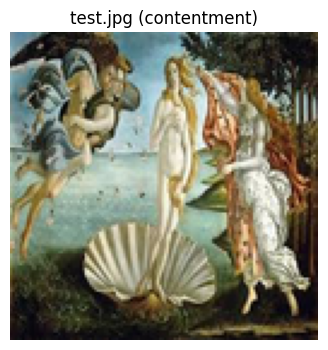

------------------------------------------------------------
VLT (Transformer) predictions:
[VLT-glove]   the woman looks like she is enjoying a nice day
[VLT-fasttext]   the man is sitting on the window and the woman looks like a <unk>
------------------------------------------------------------
CNN+LSTM predictions:
[CNN-glove]   the colors are very calming and the colors are very calming
[CNN-fasttext]   the woman is very happy and the colors are very calming
[CNN-tfidf]   the woman is in a woman 's face and the woman is very happy
------------------------------------------------------------


In [ ]:
%matplotlib inline

import sys
import importlib

sys.path.append("scripts")
sys.path.append(".")

import scripts.viva_predict

importlib.reload(scripts.viva_predict)

# Emotion IDs {
#     0: "amusement", 1: "contentment", 2: "awe", 3: "excitement",
#     4: "fear", 5: "anger", 6: "sadness", 7: "disgust", 8: "something else"}

IMAGE_NAME = "test.jpg"      
EMOTION_ID = 1               

scripts.viva_predict.predict_single_image(
    image_name=IMAGE_NAME,
    emotion_id=EMOTION_ID,
    images_root="viva_images"
)